In [7]:
!pip install wordcloud
!pip install nltk

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
from google.colab import files
uploaded = files.upload()

Saving export_curcumin.csv to export_curcumin.csv


In [10]:
df = pd.read_csv("export_curcumin.csv")
df.head()

,sn,product name,ratings,reviews,helpful,date,Unnamed: 6,asin,target,text
0,0,Turmeric Curcumin with BioPerine 95% Curcumino...,4,\n\n I've been ordering these turmeric pills ...,"2,015","September 19, 2018",NaN,B06X9T1Y3F,p,\n\n I've been ordering these turmeric pills ...
1,1,Turmeric Curcumin with BioPerine 95% Curcumino...,5,\n\n Was shocked to find white capsules mixed...,"1,296","May 16, 2019",NaN,B06X9T1Y3F,p,\n\n Was shocked to find white capsules mixed...
2,2,Turmeric Curcumin with BioPerine 95% Curcumino...,1,\n\n Let me begin with that I have a degree i...,836,"August 18, 2018",NaN,B06X9T1Y3F,n,\n\n Let me begin with that I have a degree i...
3,3,Turmeric Curcumin with BioPerine 95% Curcumino...,1,\n\n It worked get for arthritis but my husba...,659,"October 5, 2018",NaN,B06X9T1Y3F,n,\n\n It worked get for arthritis but my husba...
4,4,Turmeric Curcumin with BioPerine 95% Curcumino...,1,\n\n I took only 2 capsules instead of the 3 ...,515,"May 1, 2019",NaN,B06X9T1Y3F,n,\n\n I took only 2 capsules instead of the 3 ...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sn            5000 non-null   int64  
 1   product name  5000 non-null   object 
 2   ratings       5000 non-null   int64  
 3   reviews       5000 non-null   object 
 4   helpful       5000 non-null   object 
 5   date          5000 non-null   object 
 6   Unnamed: 6    0 non-null      float64
 7   asin          5000 non-null   object 
 8   target        5000 non-null   object 
 9   text          5000 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 390.8+ KB


In [12]:
df.shape

(5000, 10)

In [13]:
df['ratings'].value_counts()

,count
ratings,
5,3567
4,770
1,518
3,94
2,51


In [14]:
def map_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["ratings"].apply(map_sentiment)
df["sentiment"].value_counts()

,count
sentiment,
positive,4337
negative,569
neutral,94


In [15]:
df2 = df[df["sentiment"] != "neutral"].copy()
df2["sentiment"].value_counts()

,count
sentiment,
positive,4337
negative,569


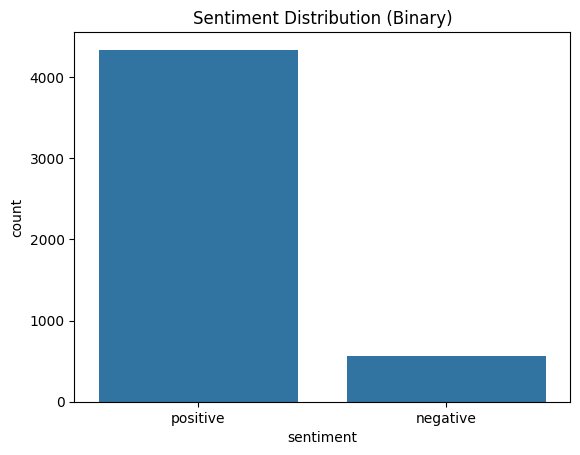

In [16]:
sns.countplot(data=df2, x="sentiment")
plt.title("Sentiment Distribution (Binary)")
plt.show()

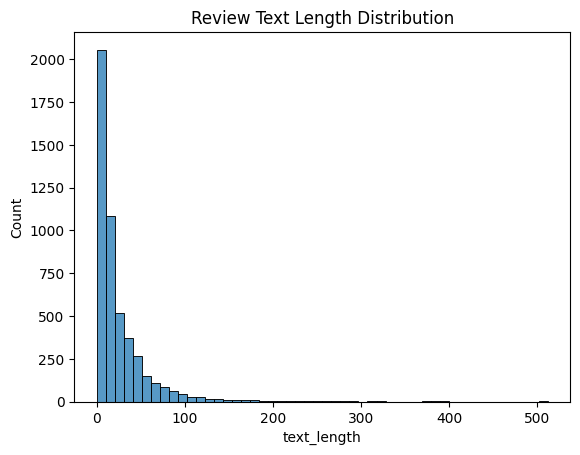

In [17]:
df2["text_length"] = df2["reviews"].astype(str).apply(lambda x: len(x.split()))
sns.histplot(df2["text_length"], bins=50)
plt.title("Review Text Length Distribution")
plt.show()

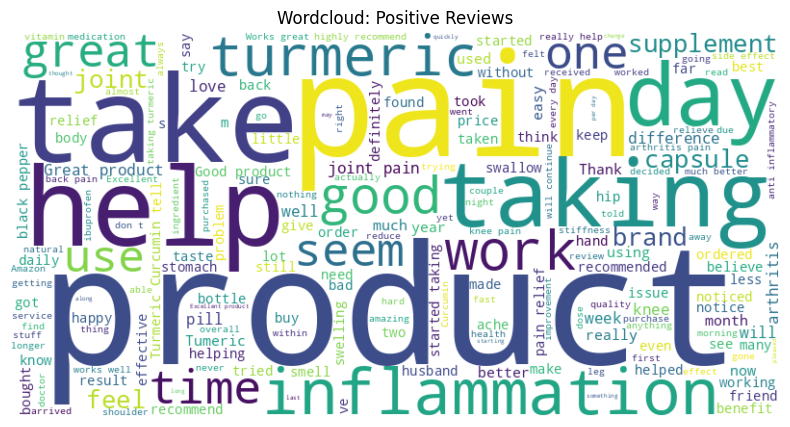

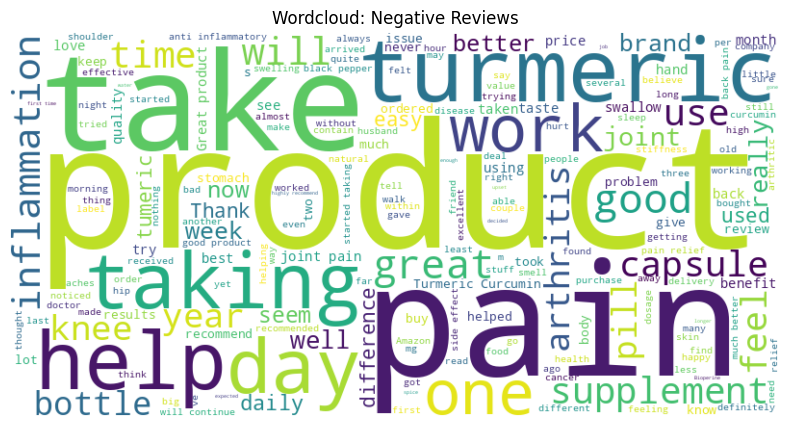

In [18]:
stopwords_set = set(STOPWORDS)

def show_wordcloud(text, title):
    wc = WordCloud(stopwords=stopwords_set,
                   background_color='white',
                   max_words=200,
                   width=800,
                   height=400).generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

# Positive
show_wordcloud(df2[df2["sentiment"]=="positive"]["reviews"].astype(str),
               "Wordcloud: Positive Reviews")

# Negative
show_wordcloud(df2[df2["sentiment"]=="negative"]["reviews"].astype(str),
               "Wordcloud: Negative Reviews")

In [19]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [20]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

df2["clean_text"] = df2["reviews"].apply(clean_text)
df2[["reviews", "clean_text"]].head()

,reviews,clean_text
0,\n\n I've been ordering these turmeric pills ...,ordering turmeric pill satisfied purchase pill...
1,\n\n Was shocked to find white capsules mixed...,shocked find white capsule mixed expected turm...
2,\n\n Let me begin with that I have a degree i...,let begin degree biology also took lot course ...
3,\n\n It worked get for arthritis but my husba...,worked get arthritis husband taken week ended ...
4,\n\n I took only 2 capsules instead of the 3 ...,took capsule instead reccomended day got nause...


In [21]:
X = df2["clean_text"]
y = df2["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [24]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       114
    positive       0.88      1.00      0.94       868

    accuracy                           0.88       982
   macro avg       0.44      0.50      0.47       982
weighted avg       0.78      0.88      0.83       982



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("Logistic Regression Performance (with class_weight='balanced'):")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance (with class_weight='balanced'):
              precision    recall  f1-score   support

    negative       0.11      0.25      0.15       114
    positive       0.88      0.73      0.80       868

    accuracy                           0.67       982
   macro avg       0.49      0.49      0.47       982
weighted avg       0.79      0.67      0.72       982



In [26]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Performance:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Performance:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       114
    positive       0.88      1.00      0.94       868

    accuracy                           0.88       982
   macro avg       0.44      0.50      0.47       982
weighted avg       0.78      0.88      0.83       982



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


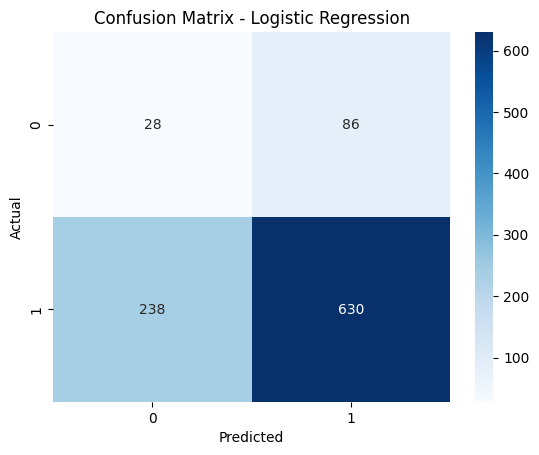

In [27]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix